# Diagrams

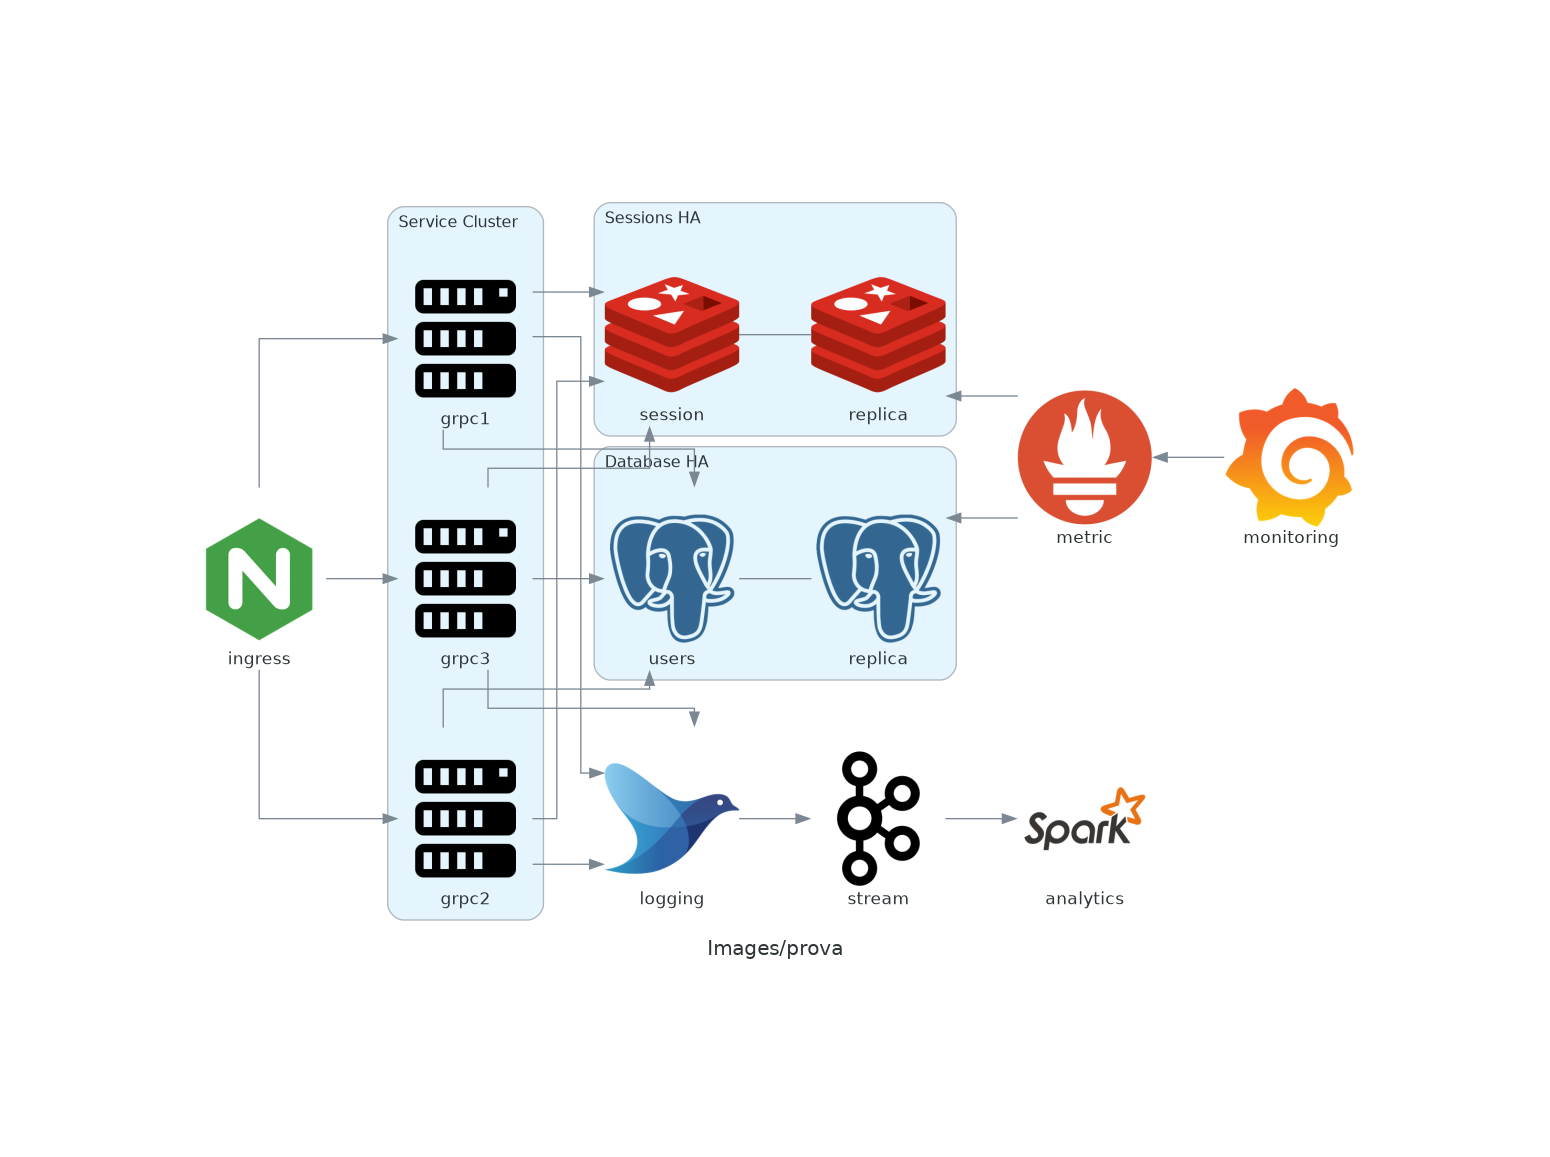

In [3]:
from diagrams import Cluster, Diagram
from diagrams.onprem.analytics import Spark
from diagrams.onprem.compute import Server
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.inmemory import Redis
from diagrams.onprem.aggregator import Fluentd
from diagrams.onprem.monitoring import Grafana, Prometheus
from diagrams.onprem.network import Nginx
from diagrams.onprem.queue import Kafka
from IPython.display import Image, display

with Diagram("Images/prova", show=False):
    ingress = Nginx("ingress")

    metrics = Prometheus("metric")
    metrics << Grafana("monitoring")

    with Cluster("Service Cluster"):
        grpcsvc = [
            Server("grpc1"),
            Server("grpc2"),
            Server("grpc3")]

    with Cluster("Sessions HA"):
        primary = Redis("session")
        primary - Redis("replica") << metrics
        grpcsvc >> primary

    with Cluster("Database HA"):
        primary = PostgreSQL("users")
        primary - PostgreSQL("replica") << metrics
        grpcsvc >> primary

    aggregator = Fluentd("logging")
    aggregator >> Kafka("stream") >> Spark("analytics")

    ingress >> grpcsvc >> aggregator

display(Image(filename="Images/prova.png"))

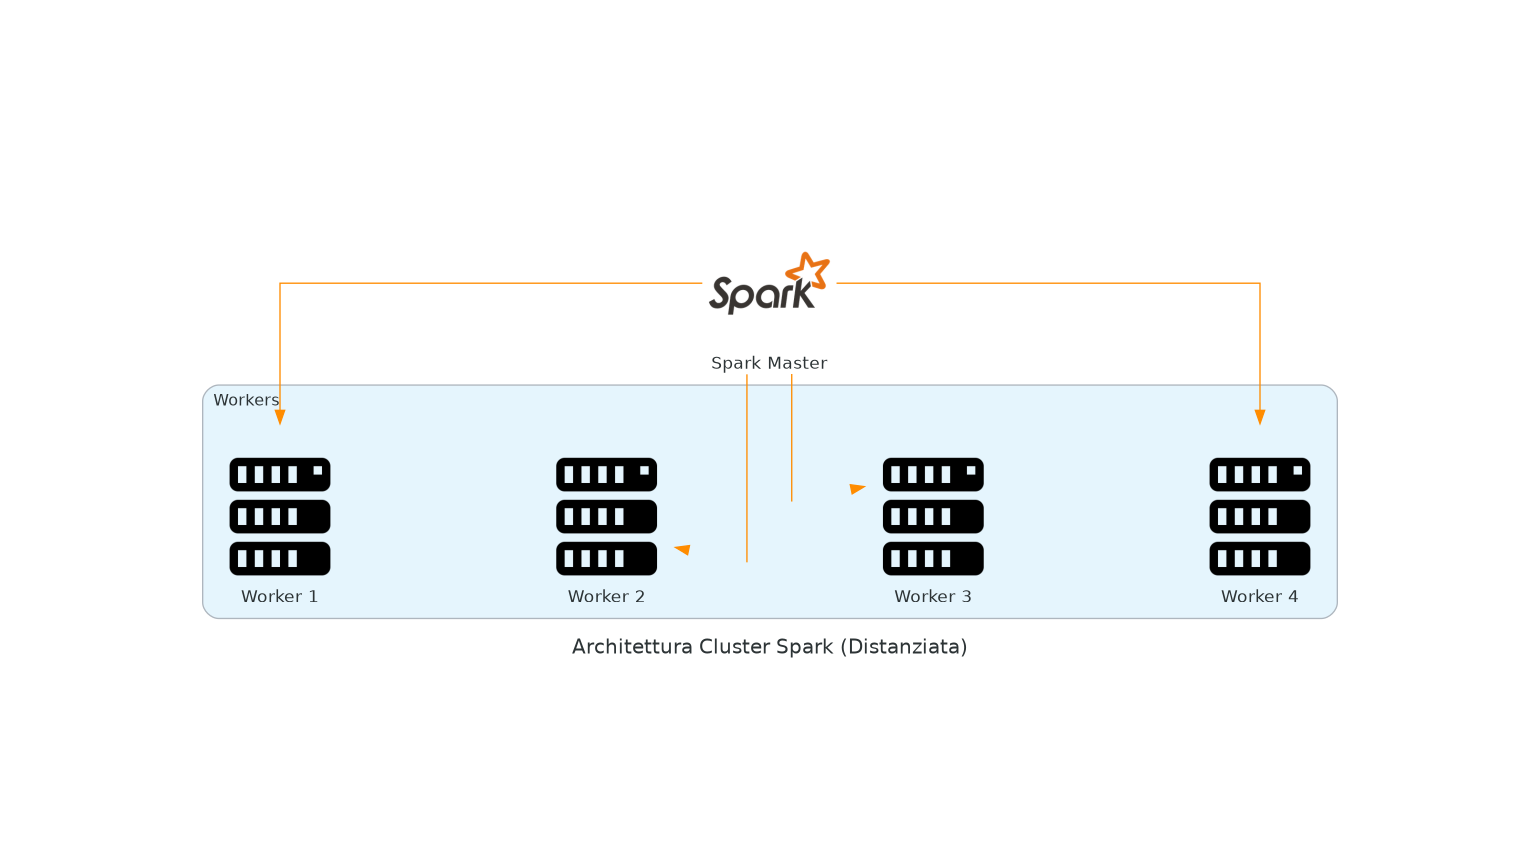

In [ ]:
from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.analytics import Spark
from diagrams.onprem.compute import Server
from IPython.display import Image, display

# Nome del file che verrà generato
file_name = "my_spark_cluster"

graph_attr = {
    "ranksep": "0.5",  # Aumenta la distanza orizzontale tra i livelli (Master -> Workers)
    "nodesep": "2"   # Aumenta la distanza verticale tra i singoli Worker
}

with Diagram("Architettura Cluster Spark (Distanziata)", 
             show=False, 
             filename=file_name,
             direction="TB",
             graph_attr=graph_attr): # Applichiamo gli attributi qui

    # Definiamo il Master (Nodo principale)
    master = Spark("Spark Master")

    # Creiamo un cluster logico per i Worker
    with Cluster("Workers"):
        workers = [Server(f"Worker {i+1}") for i in range(4)]

    # Colleghiamo il Master a tutti i Worker contemporaneamente
    # Usiamo Edge per personalizzare le frecce (opzionale)
    master >> Edge(color="darkorange") >> workers

# Visualizzazione nel Notebook
display(Image(filename=f"{file_name}.png"))

In [ ]:
from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.analytics import Spark
from IPython.display import Image, display

with Diagram("Classic K-means",
             show=False, 
             filename = "classic_kmean_diagram"):
    

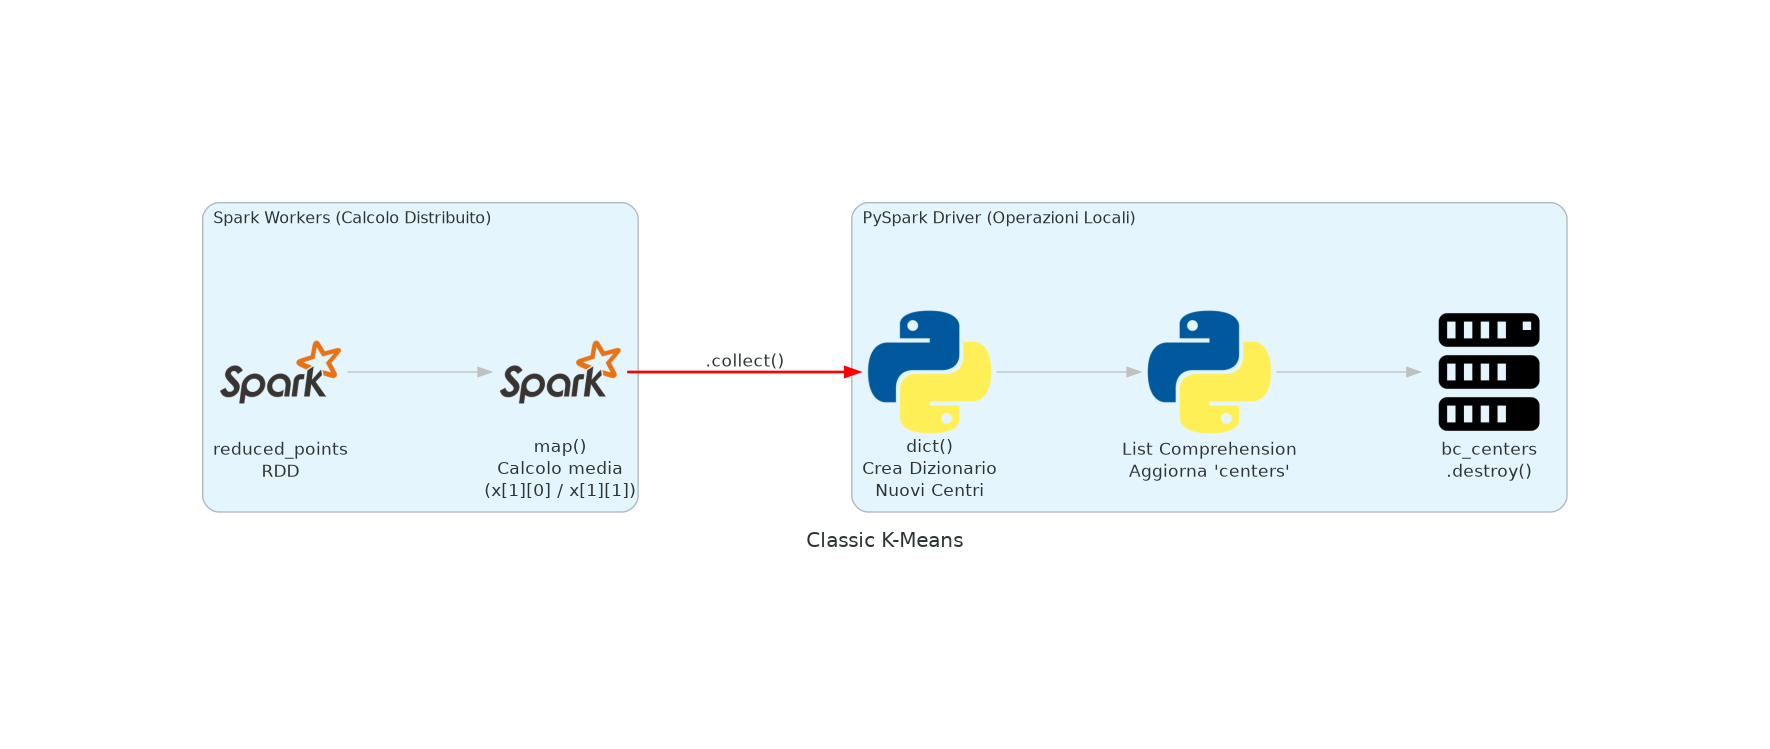

In [1]:
from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.analytics import Spark
from diagrams.onprem.compute import Server
from diagrams.programming.language import Python
from IPython.display import Image, display

file_name = "classic_kmeans_workflow"

# Attributi per dare un po' di respiro al grafico
graph_attr = {
    "rankdir": "LR",  # Flusso da sinistra a destra
    "nodesep": "0.8", # Spazio verticale tra i nodi
    "ranksep": "1.5"  # Spazio orizzontale tra le fasi
}

with Diagram("Classic K-Means",
             show=False,
             filename=file_name, 
             graph_attr=graph_attr):

    # --- FASE 1: Calcolo Distribuito (Cluster Spark) ---
    with Cluster("Spark Workers (Calcolo Distribuito)"):
        # L'RDD di partenza con (cluster_id, (somma_punti, conteggio))
        rdd_reduced = Spark("reduced_points\nRDD")
        
        # La trasformazione map che calcola i nuovi centri
        rdd_mapped = Spark("map()\nCalcolo media\n(x[1][0] / x[1][1])")
        
        # Flusso interno ai worker
        rdd_reduced >> Edge(color="gray") >> rdd_mapped

    # --- FASE 2: Aggiornamento Locale (Nodo Driver) ---
    with Cluster("PySpark Driver (Operazioni Locali)"):
        # Creazione del dizionario dai dati collezionati
        driver_dict = Python("dict()\nCrea Dizionario\nNuovi Centri")
        
        # Ricostruzione della lista (list comprehension)
        driver_list = Python("List Comprehension\nAggiorna 'centers'")
        
        # Pulizia memoria
        driver_cleanup = Server("bc_centers\n.destroy()")
        
        # Flusso interno al driver
        driver_dict >> Edge(color="gray") >> driver_list >> Edge(color="gray") >> driver_cleanup

    # --- CONNESSIONE: Da Workers a Driver ---
    # L'azione .collect() è il ponte che sposta i dati dal cluster al driver
    rdd_mapped >> Edge(label=" .collect() ", color="red", style="bold") >> driver_dict

# Comando per mostrare l'immagine nel Notebook
display(Image(filename=f"{file_name}.png"))

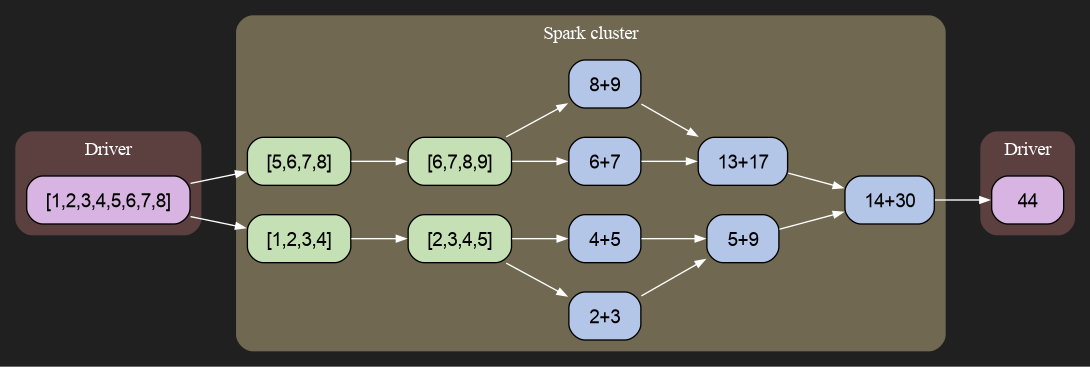

In [2]:
import graphviz
from IPython.display import display, Image

# Creiamo un nuovo grafo orientato (Digraph)
dot = graphviz.Digraph(name='MapReduce', format='png')

# Impostazioni globali del grafo
# rankdir='LR' imposta la direzione da sinistra a destra
# bgcolor imposta lo sfondo scuro (dark mode) come nell'immagine
dot.attr(rankdir='LR', splines='line', nodesep='0.3', ranksep='0.6', bgcolor='#202020')

# Stile di default per tutti i nodi (rettangoli arrotondati, font chiaro)
dot.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
# Stile di default per gli edge (frecce)
dot.attr('edge', color='white', arrowsize='0.7')

# --- DRIVER INPUT ---
with dot.subgraph(name='cluster_driver_in') as c:
    # Stile del cluster
    c.attr(label='Driver', style='filled,rounded', color='#5c4040', fontcolor='white')
    # Nodo dato
    c.node('input', '[1,2,3,4,5,6,7,8]', fillcolor='#d8b4e2', color='black')

# --- SPARK CLUSTER ---
with dot.subgraph(name='cluster_spark') as c:
    # Stile del cluster Spark
    c.attr(label='Spark cluster', style='filled,rounded', color='#706850', fontcolor='white')
    
    # -- Fase di Parallelize --
    c.node('p1', '[1,2,3,4]', fillcolor='#c5e0b4', color='black')
    c.node('p2', '[5,6,7,8]', fillcolor='#c5e0b4', color='black')
    
    # -- Fase di Map (aggiunge 1 a ogni elemento) --
    c.node('m1', '[2,3,4,5]', fillcolor='#c5e0b4', color='black')
    c.node('m2', '[6,7,8,9]', fillcolor='#c5e0b4', color='black')
    
    # -- Fase di Reduce (Combinatore locale 1) --
    c.node('r1_1', '2+3', fillcolor='#b4c6e7', color='black')
    c.node('r1_2', '4+5', fillcolor='#b4c6e7', color='black')
    c.node('r2_1', '6+7', fillcolor='#b4c6e7', color='black')
    c.node('r2_2', '8+9', fillcolor='#b4c6e7', color='black')
    
    # -- Fase di Reduce (Combinatore locale 2) --
    c.node('r3_1', '5+9', fillcolor='#b4c6e7', color='black')
    c.node('r3_2', '13+17', fillcolor='#b4c6e7', color='black')
    
    # -- Fase di Reduce (Shuffle / Globale) --
    c.node('r4', '14+30', fillcolor='#b4c6e7', color='black')

# --- DRIVER OUTPUT ---
with dot.subgraph(name='cluster_driver_out') as c:
    c.attr(label='Driver', style='filled,rounded', color='#5c4040', fontcolor='white')
    c.node('output', '44', fillcolor='#d8b4e2', color='black')

# --- COLLEGAMENTI (EDGE) ---

# Input -> Parallelize
dot.edge('input', 'p1')
dot.edge('input', 'p2')

# Parallelize -> Map
dot.edge('p1', 'm1')
dot.edge('p2', 'm2')

# Map -> Reduce 1 (divisione a coppie per la somma)
dot.edge('m1', 'r1_1')
dot.edge('m1', 'r1_2')
dot.edge('m2', 'r2_1')
dot.edge('m2', 'r2_2')

# Reduce 1 -> Reduce 2
dot.edge('r1_1', 'r3_1')
dot.edge('r1_2', 'r3_1')
dot.edge('r2_1', 'r3_2')
dot.edge('r2_2', 'r3_2')

# Reduce 2 -> Reduce globale
dot.edge('r3_1', 'r4')
dot.edge('r3_2', 'r4')

# Reduce globale -> Output (Driver)
dot.edge('r4', 'output')

# Salvataggio e visualizzazione
file_name = 'mapreduce_diagram'
dot.render(file_name, format='png', cleanup=True)
display(Image(filename=f"{file_name}.png"))

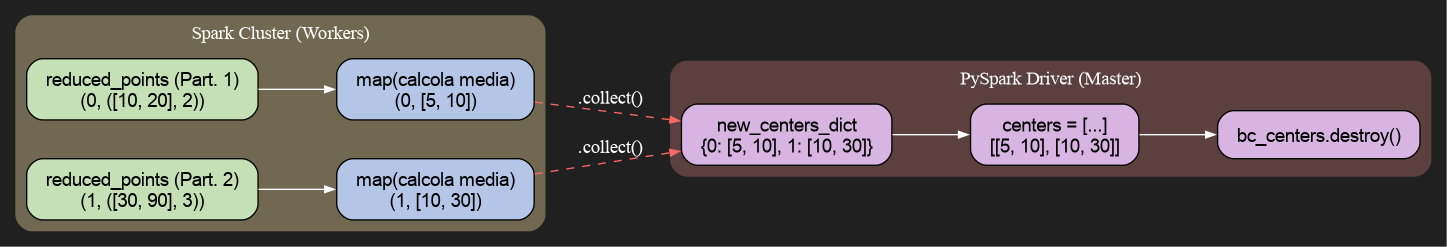

In [3]:
import graphviz
from IPython.display import display, Image

# Creiamo un nuovo grafo orientato (Digraph)
dot = graphviz.Digraph(name='KMeans_Update', format='png')

# Impostazioni globali del grafo (Tema Scuro e allineamento)
dot.attr(rankdir='LR', splines='line', nodesep='0.4', ranksep='0.8', bgcolor='#202020')

# Stile di default per tutti i nodi (rettangoli arrotondati, font chiaro)
dot.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
# Stile di default per gli edge (frecce)
dot.attr('edge', color='white', arrowsize='0.7')

# --- SPARK CLUSTER (Fase di calcolo distribuito) ---
with dot.subgraph(name='cluster_spark') as c:
    # Stile del cluster Spark
    c.attr(label='Spark Cluster (Workers)', style='filled,rounded', color='#706850', fontcolor='white')
    
    # -- Fase Iniziale: L'RDD "reduced_points" --
    # Simuliamo due partizioni con i dati nel formato: (cluster_id, (somma_coordinate, conteggio_punti))
    c.node('rdd_p1', 'reduced_points (Part. 1)\n(0, ([10, 20], 2))', fillcolor='#c5e0b4', color='black')
    c.node('rdd_p2', 'reduced_points (Part. 2)\n(1, ([30, 90], 3))', fillcolor='#c5e0b4', color='black')
    
    # -- Fase di Map: (x[0], x[1][0] / x[1][1]) --
    # Calcola il nuovo centroide (media)
    c.node('map_p1', 'map(calcola media)\n(0, [5, 10])', fillcolor='#b4c6e7', color='black')
    c.node('map_p2', 'map(calcola media)\n(1, [10, 30])', fillcolor='#b4c6e7', color='black')

# --- DRIVER (Fase di aggiornamento locale) ---
with dot.subgraph(name='cluster_driver') as c:
    c.attr(label='PySpark Driver (Master)', style='filled,rounded', color='#5c4040', fontcolor='white')
    
    # -- collect() e conversione in dict() --
    c.node('dict', 'new_centers_dict\n{0: [5, 10], 1: [10, 30]}', fillcolor='#d8b4e2', color='black')
    
    # -- List comprehension per aggiornare 'centers' --
    c.node('list', 'centers = [...]\n[[5, 10], [10, 30]]', fillcolor='#d8b4e2', color='black')
    
    # -- Pulizia memoria broadcast --
    c.node('cleanup', 'bc_centers.destroy()', fillcolor='#d8b4e2', color='black')

# --- COLLEGAMENTI (EDGE) ---

# All'interno dei Worker: reduced_points -> map
dot.edge('rdd_p1', 'map_p1')
dot.edge('rdd_p2', 'map_p2')

# Dai Worker al Driver: collect() (Shuffle di rete)
# Evidenziamo queste frecce in rosso/tratteggiate per indicare lo spostamento via rete
dot.edge('map_p1', 'dict', label=' .collect()', fontcolor='white', color='#ff6666', style='dashed')
dot.edge('map_p2', 'dict', label=' .collect()', fontcolor='white', color='#ff6666', style='dashed')

# All'interno del Driver: aggiornamento sequenziale dello stato
dot.edge('dict', 'list')
dot.edge('list', 'cleanup')

# Salvataggio e visualizzazione
file_name = 'kmeans_update_diagram'
dot.render(file_name, format='png', cleanup=True)
display(Image(filename=f"{file_name}.png"))

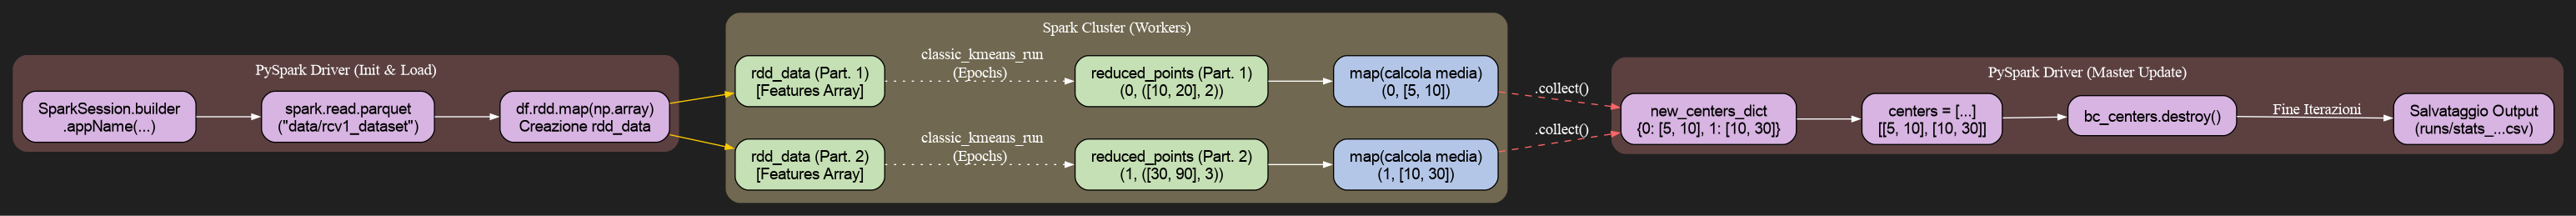

In [25]:
import graphviz
from IPython.display import display, Image

# Creiamo un nuovo grafo orientato (Digraph)
dot = graphviz.Digraph(name='KMeans_Full_Workflow', format='png')

# Impostazioni globali del grafo (Tema Scuro e allineamento)
dot.attr(rankdir='LR', splines='line', nodesep='0.4', ranksep='0.8', bgcolor='#202020')

# Stile di default per tutti i nodi (rettangoli arrotondati, font chiaro)
dot.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
# Stile di default per gli edge (frecce)
dot.attr('edge', color='white', arrowsize='0.7')

# --- DRIVER (Fase di Inizializzazione e Caricamento) ---
with dot.subgraph(name='cluster_driver_init') as c:
    c.attr(label='PySpark Driver (Init & Load)', style='filled,rounded', color='#5c4040', fontcolor='white')
    
    # Inizializzazione Sessione e Lettura Parquet
    c.node('session', 'SparkSession.builder\n.appName(...)', fillcolor='#d8b4e2', color='black')
    c.node('read_pq', 'spark.read.parquet\n("data/rcv1_dataset")', fillcolor='#d8b4e2', color='black')
    c.node('df_map', 'df.rdd.map(np.array)\nCreazione rdd_data', fillcolor='#d8b4e2', color='black')

# --- SPARK CLUSTER (Fase di calcolo distribuito) ---
with dot.subgraph(name='cluster_spark') as c:
    # Stile del cluster Spark
    c.attr(label='Spark Cluster (Workers)', style='filled,rounded', color='#706850', fontcolor='white')
    
    # -- Distribuzione Iniziale --
    c.node('rdd_init_p1', 'rdd_data (Part. 1)\n[Features Array]', fillcolor='#c5e0b4', color='black')
    c.node('rdd_init_p2', 'rdd_data (Part. 2)\n[Features Array]', fillcolor='#c5e0b4', color='black')
    
    # -- Fase di Update (all'interno di classic_kmeans_run) --
    c.node('rdd_p1', 'reduced_points (Part. 1)\n(0, ([10, 20], 2))', fillcolor='#c5e0b4', color='black')
    c.node('rdd_p2', 'reduced_points (Part. 2)\n(1, ([30, 90], 3))', fillcolor='#c5e0b4', color='black')
    
    # -- Fase di Map: (x[0], x[1][0] / x[1][1]) --
    c.node('map_p1', 'map(calcola media)\n(0, [5, 10])', fillcolor='#b4c6e7', color='black')
    c.node('map_p2', 'map(calcola media)\n(1, [10, 30])', fillcolor='#b4c6e7', color='black')

# --- DRIVER (Fase di aggiornamento locale e salvataggio) ---
with dot.subgraph(name='cluster_driver_update') as c:
    c.attr(label='PySpark Driver (Master Update)', style='filled,rounded', color='#5c4040', fontcolor='white')
    
    # -- collect() e conversione in dict() --
    c.node('dict', 'new_centers_dict\n{0: [5, 10], 1: [10, 30]}', fillcolor='#d8b4e2', color='black')
    
    # -- List comprehension per aggiornare 'centers' --
    c.node('list', 'centers = [...]\n[[5, 10], [10, 30]]', fillcolor='#d8b4e2', color='black')
    
    # -- Pulizia memoria broadcast --
    c.node('cleanup', 'bc_centers.destroy()', fillcolor='#d8b4e2', color='black')
    
    # -- Salvataggio Output Finale --
    c.node('save_csv', 'Salvataggio Output\n(runs/stats_...csv)', fillcolor='#d8b4e2', color='black')

# --- COLLEGAMENTI (EDGE) ---

# Inizializzazione (Driver Init -> Workers)
dot.edge('session', 'read_pq')
dot.edge('read_pq', 'df_map')
dot.edge('df_map', 'rdd_init_p1', color='#ffcc00') # Evidenzia la creazione RDD
dot.edge('df_map', 'rdd_init_p2', color='#ffcc00')

# Passaggio logico all'interno delle Epoche (rappresenta "classic_kmeans_run")
dot.edge('rdd_init_p1', 'rdd_p1', label=' classic_kmeans_run\n(Epochs)', fontcolor='white', style='dotted')
dot.edge('rdd_init_p2', 'rdd_p2', label=' classic_kmeans_run\n(Epochs)', fontcolor='white', style='dotted')

# All'interno dei Worker: reduced_points -> map
dot.edge('rdd_p1', 'map_p1')
dot.edge('rdd_p2', 'map_p2')

# Dai Worker al Driver: collect() (Shuffle di rete)
dot.edge('map_p1', 'dict', label=' .collect()', fontcolor='white', color='#ff6666', style='dashed')
dot.edge('map_p2', 'dict', label=' .collect()', fontcolor='white', color='#ff6666', style='dashed')

# All'interno del Driver (Update): aggiornamento sequenziale dello stato
dot.edge('dict', 'list')
dot.edge('list', 'cleanup')

# Dal Loop al Salvataggio finale
dot.edge('cleanup', 'save_csv', label=' Fine Iterazioni', fontcolor='white')

# Salvataggio e visualizzazione
file_name = 'kmeans_full_workflow'
dot.render(file_name, format='png', cleanup=True)
display(Image(filename=f"{file_name}.png"))

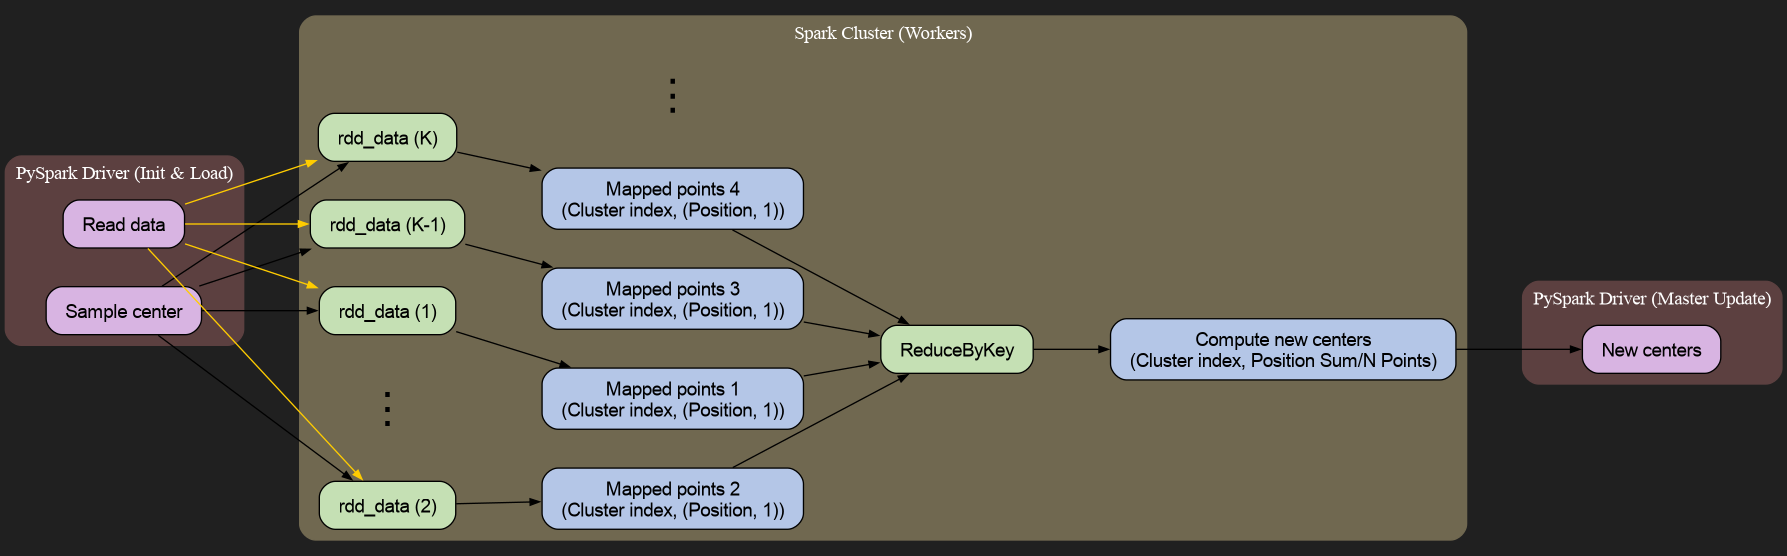

In [168]:
import graphviz
from IPython.display import display, Image

fname = 'classic_kmeans_workflow'
graph = graphviz.Digraph(name=fname, format='png')
# Rimosso ordering="out" che forzava un posizionamento sfasato ignorando i nostri invis
graph.attr(rankdir='LR', splines='line', nodesep='0.4', ranksep='0.8', bgcolor='#202020')
graph.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
graph.attr('edge', color='white', arrowsize='0.7')

# Load the data
with graph.subgraph(name='cluster_driver_init') as g:
    g.attr(label='PySpark Driver (Init & Load)', style='filled,rounded', color='#5c4040', fontcolor='white')

    with g.subgraph() as s:
        s.attr(rank='same')
        s.node('centers', 'Sample center', fillcolor='#d8b4e2', color='black', group='g3')
        s.node('read', 'Read data', fillcolor='#d8b4e2', color='black', group='g2')


# Spark cluster
with graph.subgraph(name='cluster_spark') as g:
    g.attr(label='Spark Cluster (Workers)', style='filled,rounded', color='#706850', fontcolor='white')

    with g.subgraph() as s_rdd:
        s_rdd.attr(rank='same', ordering='out')
        s_rdd.node('rdd_data1', 'rdd_data (1)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data2', 'rdd_data (2)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='32')
        s_rdd.node('rdd_data3', 'rdd_data (K-1)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data4', 'rdd_data (K)', fillcolor='#c5e0b4', color='black')
        
        s_rdd.edge('rdd_data1', 'rdd_data2', style='invis', weight="100")
        s_rdd.edge('rdd_data2', 'rdd_dots', style='invis', weight="100")
        s_rdd.edge('rdd_dots', 'rdd_data3', style='invis', weight="100")
        s_rdd.edge('rdd_data3', 'rdd_data4', style='invis', weight="100")

    with g.subgraph() as s_map:
        s_map.attr(rank='same', ordering='out')
        s_map.node('map_p1', 'Mapped points 1\n(Cluster index, (Position, 1))', fillcolor='#b4c6e7', color='black')
        s_map.node('map_p2', 'Mapped points 2\n(Cluster index, (Position, 1))', fillcolor='#b4c6e7', color='black')
        s_map.node('map_pk', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='32')
        s_map.node('map_p3', 'Mapped points 3\n(Cluster index, (Position, 1))', fillcolor='#b4c6e7', color='black')
        s_map.node('map_p4', 'Mapped points 4\n(Cluster index, (Position, 1))', fillcolor='#b4c6e7', color='black')
        
        s_map.edge('map_p1', 'map_p2', style='invis', weight="100")
        s_map.edge('map_p2', 'map_pk', style='invis', weight="100")
        s_map.edge('map_pk', 'map_p3', style='invis', weight="100")
        s_map.edge('map_p3', 'map_p4', style='invis', weight="100")


    # -- Reduce --
    g.node('reduce', 'ReduceByKey', fillcolor='#c5e0b4', color='black')

    # -- Compute --
    g.node('comp_new_centers', 'Compute new centers\n(Cluster index, Position Sum/N Points)', fillcolor='#b4c6e7', color='black')


# Driver Update
with graph.subgraph(name='cluster_driver_update') as g:
    g.attr(label='PySpark Driver (Master Update)', style='filled,rounded', color='#5c4040', fontcolor='white')
    g.node('new_centers', 'New centers', fillcolor='#d8b4e2', color='black')


# --- COLLEGAMENTI (EDGES) ---

# Read verso RDD
graph.edge('read', 'rdd_data1', color='#ffcc00', weight="10")
graph.edge('read', 'rdd_data2', color='#ffcc00', weight="1")
graph.edge('read', 'rdd_data3', color='#ffcc00', weight="1")
graph.edge('read', 'rdd_data4', color='#ffcc00', weight="1")

graph.edge('centers', 'rdd_data1', color="#000000", weight="10")
graph.edge('centers', 'rdd_data2', color="#000000", weight="1")
graph.edge('centers', 'rdd_data3', color="#000000", weight="1")
graph.edge('centers', 'rdd_data4', color="#000000", weight="1")

# RDD verso Map
graph.edge('rdd_data1', 'map_p1', color="#000000", weight="10")
graph.edge('rdd_data2', 'map_p2', color="#000000", weight="10")
graph.edge('rdd_data3', 'map_p3', color="#000000", weight="10")
graph.edge('rdd_data4', 'map_p4', color="#000000", weight="10")

# Map verso Reduce
graph.edge('map_p1', 'reduce', color="#000000", weight="1")
graph.edge('map_p2', 'reduce', color="#000000", weight="1")
graph.edge('map_p3', 'reduce', color="#000000", weight="1")
graph.edge('map_p4', 'reduce', color="#000000", weight="1")

# Fase finale
graph.edge('reduce', 'comp_new_centers', color="#000000")
graph.edge('comp_new_centers', 'new_centers', color="#000000")

# -- Loop tratteggiato -- 
#graph.edge('new_centers:s', 'centers:s', color="#f70000", style="dashed", constraint="false", label=" Update Centers (Epochs)")

graph.render("images/" + fname, format='png', cleanup=True)
display(Image(filename=f"images/{fname}.png"))

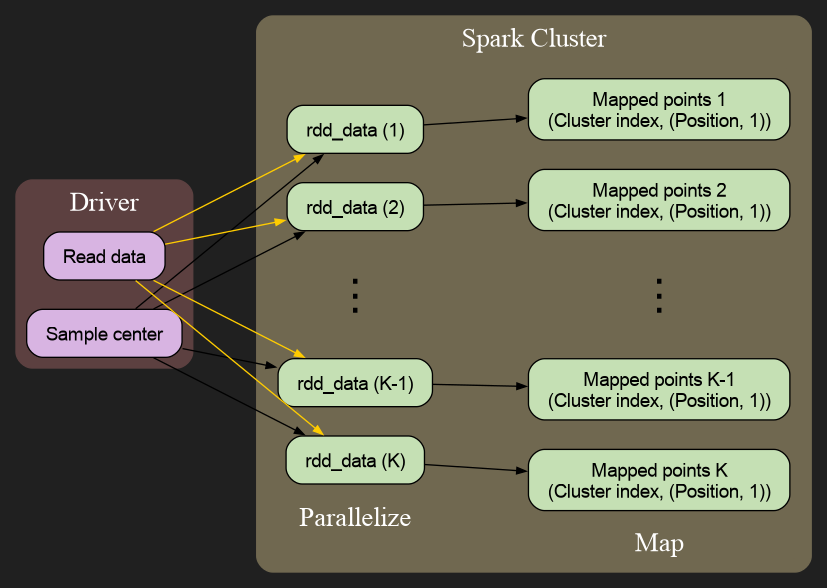

In [265]:
import graphviz
from IPython.display import display, Image

fname = 'classic_kmeans_workflow'
graph = graphviz.Digraph(name=fname, format='png')
graph.attr(rankdir='LR', splines='line', nodesep='0.3', ranksep='1.0', bgcolor='#202020')
graph.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
graph.attr('edge', color='white', arrowsize='0.7')

# Load the data
with graph.subgraph(name='cluster_driver_init') as g:
    g.attr(label='Driver', style='filled,rounded', color='#5c4040', fontcolor='white', fontsize='20')

    with g.subgraph() as s:
        s.attr(rank='same')
        s.node('centers', 'Sample center', fillcolor='#d8b4e2', color='black', group='g3')
        s.node('read', 'Read data', fillcolor='#d8b4e2', color='black', group='g2')


# Spark cluster
with graph.subgraph(name='cluster_spark') as g:
    g.attr(label='Spark Cluster', style='filled,rounded', color='#706850', fontcolor='white', fontsize='20')
    
    with g.subgraph(name='cluster_rdd') as s_rdd:
        s_rdd.attr(label="Parallelize", labelloc="b", color='#706850')
        s_rdd.node('rdd_data2', 'rdd_data (2)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data1', 'rdd_data (1)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='32')
        s_rdd.node('rdd_data_k', 'rdd_data (K)', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data_k1', 'rdd_data (K-1)', fillcolor='#c5e0b4', color='black')
        
    # -- Map -- 
    with g.subgraph(name='cluster_map') as s_map:
        s_map.attr(label="Map", labelloc="b", color='#706850')
        #s_map.attr(rank='same', ordering='in')
        s_map.node('map_p1', 'Mapped points 1\n(Cluster index, (Position, 1))', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p2', 'Mapped points 2\n(Cluster index, (Position, 1))', fillcolor='#c5e0b4', color='black')
        s_map.node('map_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='32')
        s_map.node('map_p3', 'Mapped points K-1\n(Cluster index, (Position, 1))', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p4', 'Mapped points K\n(Cluster index, (Position, 1))', fillcolor='#c5e0b4', color='black')


# Arrow
graph.edge('read', 'rdd_data1', color='#ffcc00')
graph.edge('read', 'rdd_data2', color='#ffcc00')
#graph.edge('read', 'rdd_dots', style='invis')
graph.edge('read', 'rdd_data_k1', color='#ffcc00')
graph.edge('read', 'rdd_data_k', color='#ffcc00')

graph.edge('centers', 'rdd_data1', color="#000000")
graph.edge('centers', 'rdd_data2', color="#000000")
#graph.edge('centers', 'rdd_dots', style='invis')
graph.edge('centers', 'rdd_data_k1', color="#000000")
graph.edge('centers', 'rdd_data_k', color="#000000")

graph.edge('rdd_data1', 'map_p1', color="#000000")
graph.edge('rdd_data2', 'map_p2', color="#000000")
graph.edge('rdd_dots', 'map_dots', style='invis')
graph.edge('rdd_data_k1', 'map_p3', color="#000000")
graph.edge('rdd_data_k', 'map_p4', color="#000000")

graph.render("images/" + fname, format='png', cleanup=True)
display(Image(filename=f"images/{fname}.png"))

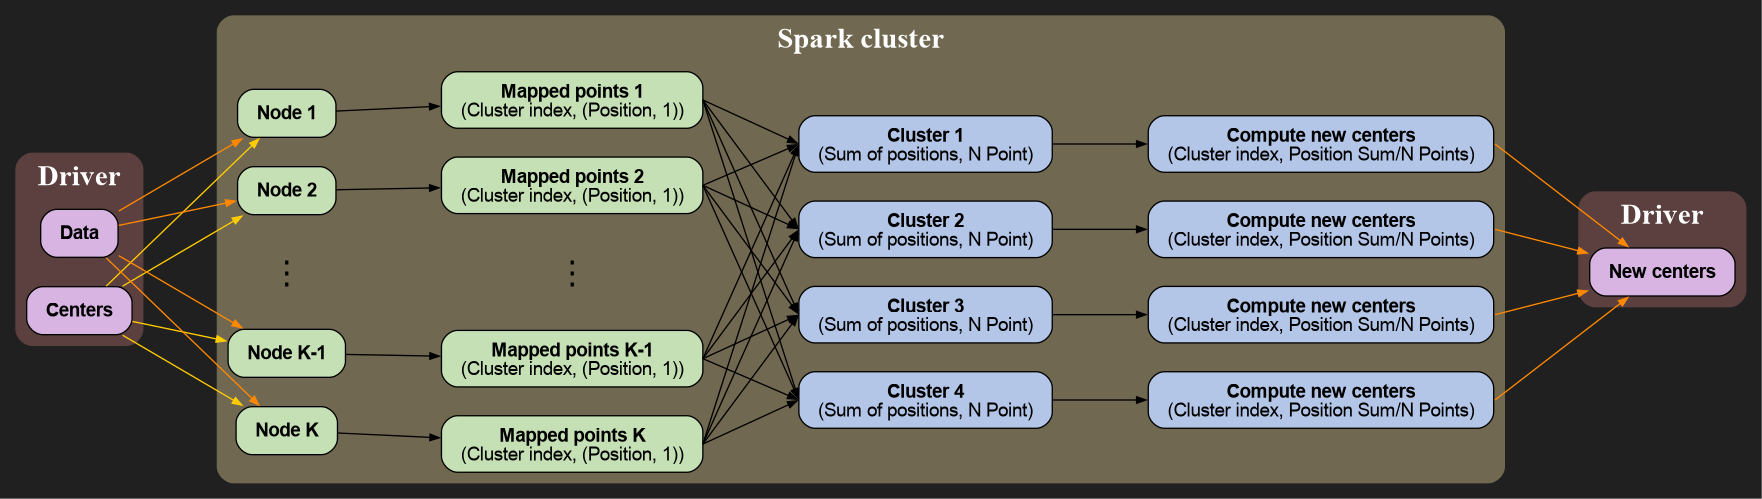

In [36]:
import graphviz
from IPython.display import display, Image

fname = 'classic_kmeans_workflow'
graph = graphviz.Digraph(name=fname, format='png')
graph.attr(rankdir='LR', splines='line', nodesep='0.3', ranksep='1.0', bgcolor='#202020')
graph.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
graph.attr('edge', color='white', arrowsize='0.7')

# Load the data
with graph.subgraph(name='cluster_driver_init') as g:
    g.attr(label='<<B>Driver</B>>', style='filled,rounded', color='#5c4040', fontcolor='white', fontsize='22')

    with g.subgraph() as s:
        s.attr(rank='same')
        s.node('centers', '<<B>Centers</B>>', fillcolor='#d8b4e2', color='black', group='g3')
        s.node('read', '<<B>Data</B>>', fillcolor='#d8b4e2', color='black', group='g2')


# Spark cluster
with graph.subgraph(name='cluster_spark') as g:
    g.attr(label='<<B>Spark cluster</B><BR/>>', style='filled,rounded', color='#706850', fontcolor='white', fontsize='22')
    
    with g.subgraph() as s_rdd:
        s_rdd.attr(rank='same')
        s_rdd.node('rdd_data2', '<<B>Node 2</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data1', '<<B>Node 1</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='24')
        s_rdd.node('rdd_data_k', '<<B>Node K</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data_k1', '<<B>Node K-1</B>>', fillcolor='#c5e0b4', color='black')
        
    # -- Map -- 
    with g.subgraph() as s_map:
        s_map.attr(rank='same', ordering='in')
        s_map.node('map_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='24')
        s_map.node('map_p1', '<<B>Mapped points 1</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p2', '<<B>Mapped points 2</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p3', '<<B>Mapped points K-1</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p4', '<<B>Mapped points K</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')

    # -- Reduce --
    with g.subgraph() as s_clu:
        s_clu.node('cluster4', '<<B>Cluster 4</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster3', '<<B>Cluster 3</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster2', '<<B>Cluster 2</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster1', '<<B>Cluster 1</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')


    # -- Map --
    g.node('comp_new_centers1', '<<B>Compute new centers</B><BR/>(Cluster index, Position Sum/N Points)>', fillcolor='#b4c6e7', color='black')
    g.node('comp_new_centers2', '<<B>Compute new centers</B><BR/>(Cluster index, Position Sum/N Points)>', fillcolor='#b4c6e7', color='black')
    g.node('comp_new_centers3', '<<B>Compute new centers</B><BR/>(Cluster index, Position Sum/N Points)>', fillcolor='#b4c6e7', color='black')
    g.node('comp_new_centers4', '<<B>Compute new centers</B><BR/>(Cluster index, Position Sum/N Points)>', fillcolor='#b4c6e7', color='black')


with graph.subgraph(name='cluster_driver_update') as g:
    g.attr(label='<<B>Driver</B>>', style='filled,rounded', color='#5c4040', fontcolor='white', fontsize='22')
    
    g.node('new_centers', '<<B>New centers</B>>', fillcolor='#d8b4e2', color='black')

# Arrow
graph.edge('read', 'rdd_data1', color='#ff8800')
graph.edge('read', 'rdd_data2', color='#ff8800')
#graph.edge('read', 'rdd_dots', style='invis')
graph.edge('read', 'rdd_data_k1', color='#ff8800')
graph.edge('read', 'rdd_data_k', color='#ff8800')

graph.edge('centers', 'rdd_data1', color="#ffcc00")
graph.edge('centers', 'rdd_data2', color="#ffcc00")
#graph.edge('centers', 'rdd_dots', style='invis')
graph.edge('centers', 'rdd_data_k1', color="#ffcc00")
graph.edge('centers', 'rdd_data_k', color="#ffcc00")

graph.edge('rdd_data1', 'map_p1', color="#000000")
graph.edge('rdd_data2', 'map_p2', color="#000000")
graph.edge('rdd_dots', 'map_dots', style='invis')
graph.edge('rdd_data_k1', 'map_p3', color="#000000")
graph.edge('rdd_data_k', 'map_p4', color="#000000")

graph.edge('map_p1:e', 'cluster1:w', color="#000000")
graph.edge('map_p1:e', 'cluster2:w', color="#000000")
graph.edge('map_p1:e', 'cluster3:w', color="#000000")
graph.edge('map_p1:e', 'cluster4:w', color="#000000")
graph.edge('map_p2:e', 'cluster1:w', color="#000000")
graph.edge('map_p2:e', 'cluster2:w', color="#000000")
graph.edge('map_p2:e', 'cluster3:w', color="#000000")
graph.edge('map_p2:e', 'cluster4:w', color="#000000")
graph.edge('map_dots:e', 'cluster1:w', style='invis')
graph.edge('map_dots:e', 'cluster2:w', style='invis')
graph.edge('map_dots:e', 'cluster3:w', style='invis')
graph.edge('map_dots:e', 'cluster4:w', style='invis')
graph.edge('map_p3:e', 'cluster1:w', color="#000000")
graph.edge('map_p3:e', 'cluster2:w', color="#000000")
graph.edge('map_p3:e', 'cluster3:w', color="#000000")
graph.edge('map_p3:e', 'cluster4:w', color="#000000")
graph.edge('map_p4:e', 'cluster1:w', color="#000000")
graph.edge('map_p4:e', 'cluster2:w', color="#000000")
graph.edge('map_p4:e', 'cluster3:w', color="#000000")
graph.edge('map_p4:e', 'cluster4:w', color="#000000")

graph.edge('cluster1', 'comp_new_centers1', color="#000000")
graph.edge('cluster2', 'comp_new_centers2', color="#000000")
graph.edge('cluster3', 'comp_new_centers3', color="#000000")
graph.edge('cluster4', 'comp_new_centers4', color="#000000")

graph.edge('comp_new_centers1:e', 'new_centers', color="#ff8800")
graph.edge('comp_new_centers2:e', 'new_centers', color="#ff8800")
graph.edge('comp_new_centers3:e', 'new_centers', color="#ff8800")
graph.edge('comp_new_centers4:e', 'new_centers', color="#ff8800")

graph.render("images/" + fname, format='svg', cleanup=True)
graph.render("images/" + fname, format='png', cleanup=True)
display(Image(filename=f"images/{fname}.png"))

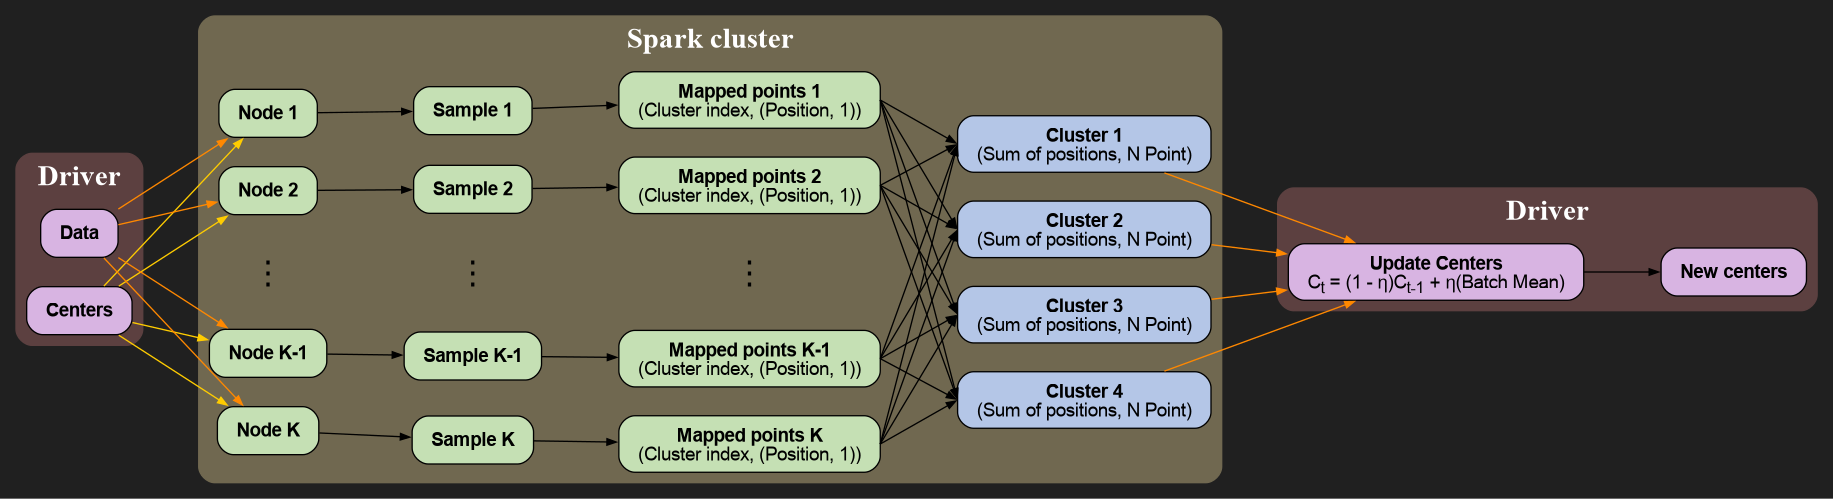

In [35]:
import graphviz
from IPython.display import display, Image

fname = 'minibatch_kmeans_workflow'
graph = graphviz.Digraph(name=fname, format='png')
graph.attr(rankdir='LR', splines='line', nodesep='0.3', ranksep='0.8', bgcolor="#202020")
graph.attr('node', shape='box', style='filled,rounded', fontname='Helvetica', margin='0.2,0.1')
graph.attr('edge', color='white', arrowsize='0.7')

# Load the data
with graph.subgraph(name='cluster_driver_init') as g:
    g.attr(label='<<B>Driver</B>>', style='filled,rounded', color='#5c4040', fontcolor='white', fontsize='22')

    with g.subgraph() as s:
        s.attr(rank='same')
        s.node('centers', '<<B>Centers</B>>', fillcolor='#d8b4e2', color='black', group='g3')
        s.node('read', '<<B>Data</B>>', fillcolor='#d8b4e2', color='black', group='g2')


# Spark cluster
with graph.subgraph(name='cluster_spark') as g:
    g.attr(label='<<B>Spark cluster</B><BR/>>', style='filled,rounded', color='#706850', fontcolor='white', fontsize='22')
    
    with g.subgraph() as s_rdd:
        #s_rdd.attr(label="Parallelize", labelloc="b", style="dashed", color="gray")
        s_rdd.attr(rank='same')
        s_rdd.node('rdd_data2', '<<B>Node 2</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data1', '<<B>Node 1</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='24')
        s_rdd.node('rdd_data_k', '<<B>Node K</B>>', fillcolor='#c5e0b4', color='black')
        s_rdd.node('rdd_data_k1', '<<B>Node K-1</B>>', fillcolor='#c5e0b4', color='black')

    with g.subgraph() as s_sam:
        #s_rdd.attr(label="Parallelize", labelloc="b", style="dashed", color="gray")
        s_sam.attr(rank='same')
        s_sam.node('sample2', '<<B>Sample 2</B>>', fillcolor='#c5e0b4', color='black')
        s_sam.node('sample1', '<<B>Sample 1</B>>', fillcolor='#c5e0b4', color='black')
        s_sam.node('sample_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='24')
        s_sam.node('sample_k', '<<B>Sample K</B>>', fillcolor='#c5e0b4', color='black')
        s_sam.node('sample_k1', '<<B>Sample K-1</B>>', fillcolor='#c5e0b4', color='black')
        
    # -- Map -- 
    with g.subgraph() as s_map:
        s_map.attr(rank='same', ordering='in')
        s_map.node('map_dots', '⋮', shape='plaintext', style='none', fontcolor='black', fontsize='24')
        s_map.node('map_p1', '<<B>Mapped points 1</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p2', '<<B>Mapped points 2</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p3', '<<B>Mapped points K-1</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')
        s_map.node('map_p4', '<<B>Mapped points K</B><BR/>(Cluster index, (Position, 1))>', fillcolor='#c5e0b4', color='black')

    # -- Reduce --
    with g.subgraph() as s_clu:
        s_clu.node('cluster4', '<<B>Cluster 4</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster3', '<<B>Cluster 3</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster2', '<<B>Cluster 2</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')
        s_clu.node('cluster1', '<<B>Cluster 1</B><BR/>(Sum of positions, N Point)>', fillcolor='#b4c6e7', color='black')


with graph.subgraph(name='cluster_driver_update') as g:
    g.attr(label='<<B>Driver</B>>', style='filled,rounded', color='#5c4040', fontcolor='white', fontsize='22')

    g.node('compute_new_centers', '<<B>Update Centers</B><BR/>C<SUB>t</SUB> = (1 - &eta;)C<SUB>t-1</SUB> + &eta;(Batch Mean)>', fillcolor='#d8b4e2', color='black')
    
    g.node('new_centers', '<<B>New centers</B>>', fillcolor='#d8b4e2', color='black')

# Arrow
graph.edge('read', 'rdd_data1', color='#ff8800')
graph.edge('read', 'rdd_data2', color='#ff8800')
#graph.edge('read', 'rdd_dots', style='invis')
graph.edge('read', 'rdd_data_k1', color='#ff8800')
graph.edge('read', 'rdd_data_k', color='#ff8800')

graph.edge('centers', 'rdd_data1', color="#ffcc00")
graph.edge('centers', 'rdd_data2', color="#ffcc00")
#graph.edge('centers', 'rdd_dots', style='invis')
graph.edge('centers', 'rdd_data_k1', color="#ffcc00")
graph.edge('centers', 'rdd_data_k', color="#ffcc00")

graph.edge('rdd_data1', 'sample1', color="#000000")
graph.edge('rdd_data2', 'sample2', color="#000000")
graph.edge('rdd_dots', 'sample_dots', style='invis')
graph.edge('rdd_data_k1', 'sample_k1', color="#000000")
graph.edge('rdd_data_k', 'sample_k', color="#000000")

graph.edge('sample1', 'map_p1', color="#000000")
graph.edge('sample2', 'map_p2', color="#000000")
graph.edge('sample_dots', 'map_dots', style='invis')
graph.edge('sample_k1', 'map_p3', color="#000000")
graph.edge('sample_k', 'map_p4', color="#000000")

graph.edge('map_p1:e', 'cluster1:w', color="#000000")
graph.edge('map_p1:e', 'cluster2:w', color="#000000")
graph.edge('map_p1:e', 'cluster3:w', color="#000000")
graph.edge('map_p1:e', 'cluster4:w', color="#000000")
graph.edge('map_p2:e', 'cluster1:w', color="#000000")
graph.edge('map_p2:e', 'cluster2:w', color="#000000")
graph.edge('map_p2:e', 'cluster3:w', color="#000000")
graph.edge('map_p2:e', 'cluster4:w', color="#000000")
graph.edge('map_dots:e', 'cluster1:w', style='invis')
graph.edge('map_dots:e', 'cluster2:w', style='invis')
graph.edge('map_dots:e', 'cluster3:w', style='invis')
graph.edge('map_dots:e', 'cluster4:w', style='invis')
graph.edge('map_p3:e', 'cluster1:w', color="#000000")
graph.edge('map_p3:e', 'cluster2:w', color="#000000")
graph.edge('map_p3:e', 'cluster3:w', color="#000000")
graph.edge('map_p3:e', 'cluster4:w', color="#000000")
graph.edge('map_p4:e', 'cluster1:w', color="#000000")
graph.edge('map_p4:e', 'cluster2:w', color="#000000")
graph.edge('map_p4:e', 'cluster3:w', color="#000000")
graph.edge('map_p4:e', 'cluster4:w', color="#000000")

graph.edge('cluster1', 'compute_new_centers', color="#ff8800")
graph.edge('cluster2', 'compute_new_centers', color="#ff8800")
graph.edge('cluster3', 'compute_new_centers', color="#ff8800")
graph.edge('cluster4', 'compute_new_centers', color="#ff8800")

graph.edge('compute_new_centers', 'new_centers', color="#000000")

graph.render("images/" + fname, format='svg', cleanup=True)
graph.render("images/" + fname, format='png', cleanup=True)
display(Image(filename=f"images/{fname}.png"))